# Data Exploration & Preprocessing

**Dataset:** CERT Insider Threat Test Dataset v4.1 (synthetic enterprise logs, ~1000 users, ~18 months)


## 1. Setup

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

In [3]:
DATA_DIR = Path('../r4.1')
ART_DIR = Path('../artifacts')
ART_DIR.mkdir(exist_ok=True)

## 2. File inventory

In [ ]:
files = sorted(p for p in DATA_DIR.iterdir() if p.is_file())
inv = pd.DataFrame({
    'file': [p.name for p in files],
    'size_mb': [round(p.stat().st_size / 1024 / 1024, 2) for p in files],
})
inv = inv.sort_values('size_mb', ascending=False).reset_index(drop=True)
inv

,file,size_mb
0,http.csv,14390.75
1,email.csv,1350.20
2,file.csv,171.64
3,logon.csv,58.69
4,device.csv,29.81
5,psychometric.csv,0.04
6,readme.txt,0.01
7,license.txt,0.00


## 3. Psychometric profile (Big Five)

The smallest file — one row per user with O / C / E / A / N scores.

In [6]:
psych = pd.read_csv(DATA_DIR / 'psychometric.csv')

In [7]:
psych.shape

(1000, 7)

In [8]:
psych.head()

,employee_name,user_id,O,C,E,A,N
0,Yvette Vivien Donovan,YVD0093,38,19,29,15,36
1,Troy Alvin Craig,TAC0118,34,40,24,15,34
2,Eden Jocelyn Mcclain,EJM0952,20,37,48,35,34
3,Alexa Emma Wood,AEW0655,25,20,18,40,38
4,Celeste Maris Griffith,CMG0936,36,13,18,50,29


In [9]:
psych.dtypes

employee_name    object
user_id          object
O                 int64
C                 int64
E                 int64
A                 int64
N                 int64
dtype: object

In [10]:
psych.isna().sum()

employee_name    0
user_id          0
O                0
C                0
E                0
A                0
N                0
dtype: int64

In [11]:
psych['user_id'].is_unique

True

In [12]:
psych[['O','C','E','A','N']].describe().round(2)

,O,C,E,A,N
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,33.51,31.53,29.10,29.00,29.52
std,10.46,10.89,11.23,11.09,5.02
min,10.00,10.00,10.00,10.00,13.00
25%,24.00,21.00,19.00,19.00,26.00
50%,37.00,35.00,28.00,28.00,30.00
75%,41.25,40.00,39.00,39.00,33.00
max,50.00,50.00,50.00,50.00,47.00


1000 unique user_id's, no missing values, integer scales roughly 10–50. Means cluster in the high 20s / low 30s. N (Neuroticism) has the tightest spread (std ≈ 5) — it may be less discriminative than O / C / E / A.

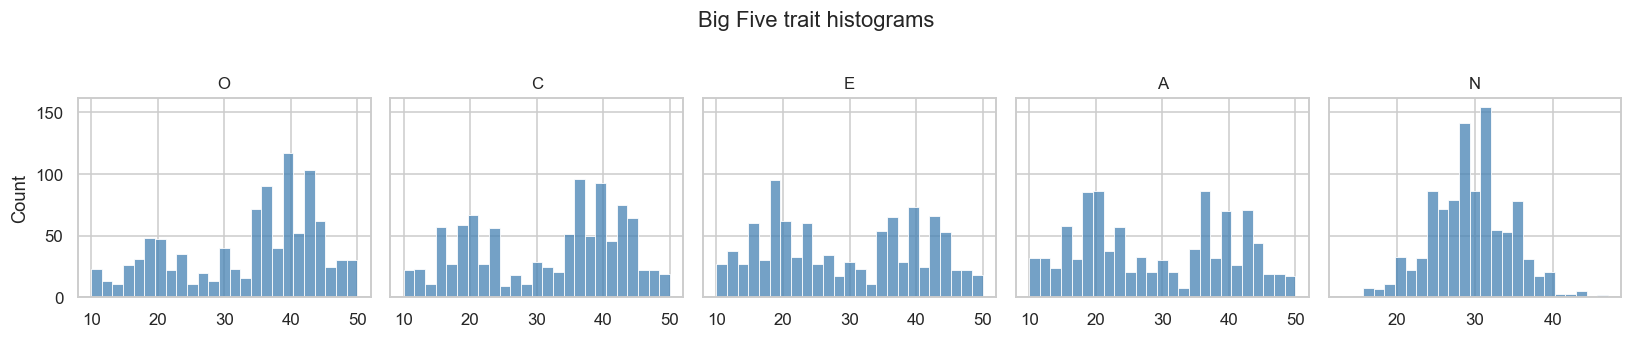

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, trait in zip(axes, list('OCEAN')):
    sns.histplot(psych[trait], bins=25, ax=ax, color='steelblue')
    ax.set_title(trait)
    ax.set_xlabel('')
plt.suptitle('Big Five trait histograms', y=1.02)
plt.tight_layout()
plt.show()

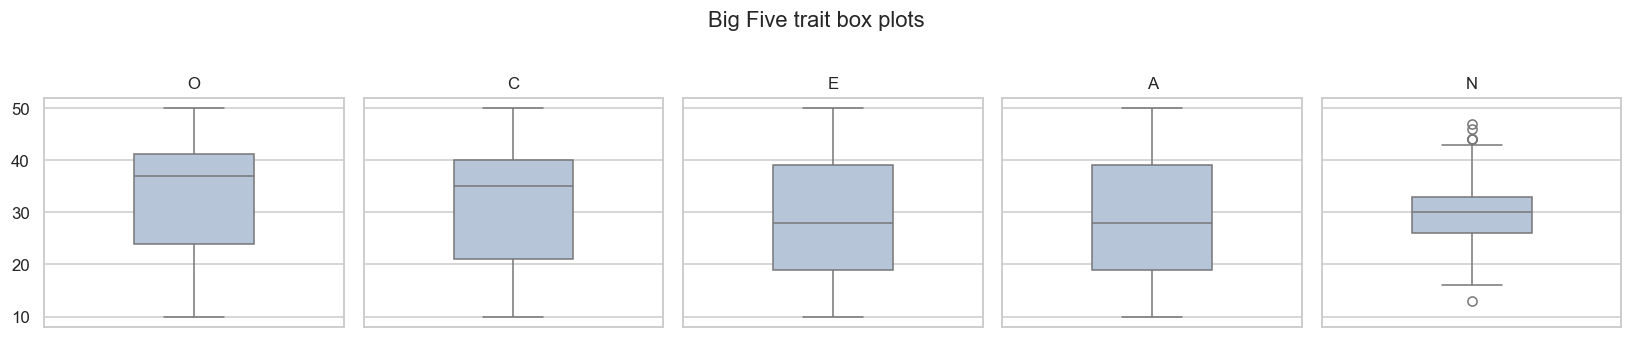

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, trait in zip(axes, list('OCEAN')):
    sns.boxplot(y=psych[trait], ax=ax, color='lightsteelblue', width=0.4)
    ax.set_title(trait)
    ax.set_ylabel('')
plt.suptitle('Big Five trait box plots', y=1.02)
plt.tight_layout()
plt.show()

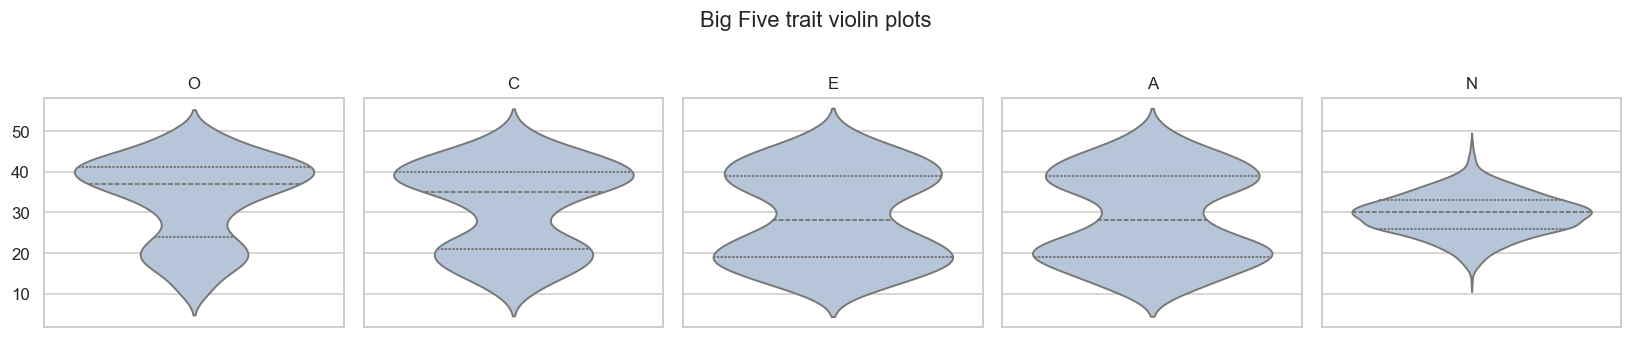

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, trait in zip(axes, list('OCEAN')):
    sns.violinplot(y=psych[trait], ax=ax, color='lightsteelblue', inner='quartile')
    ax.set_title(trait)
    ax.set_ylabel('')
plt.suptitle('Big Five trait violin plots', y=1.02)
plt.tight_layout()
plt.show()

Each trait is fairly uniform / mildly bimodal between roughly 15 and 45 — no single trait dominates and there are no extreme outliers. `N` is clearly the narrowest.

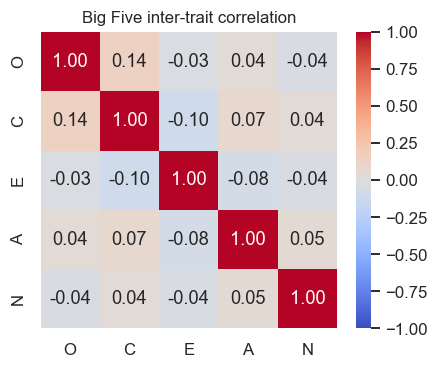

In [16]:
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(psych[list('OCEAN')].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Big Five inter-trait correlation')
plt.show()

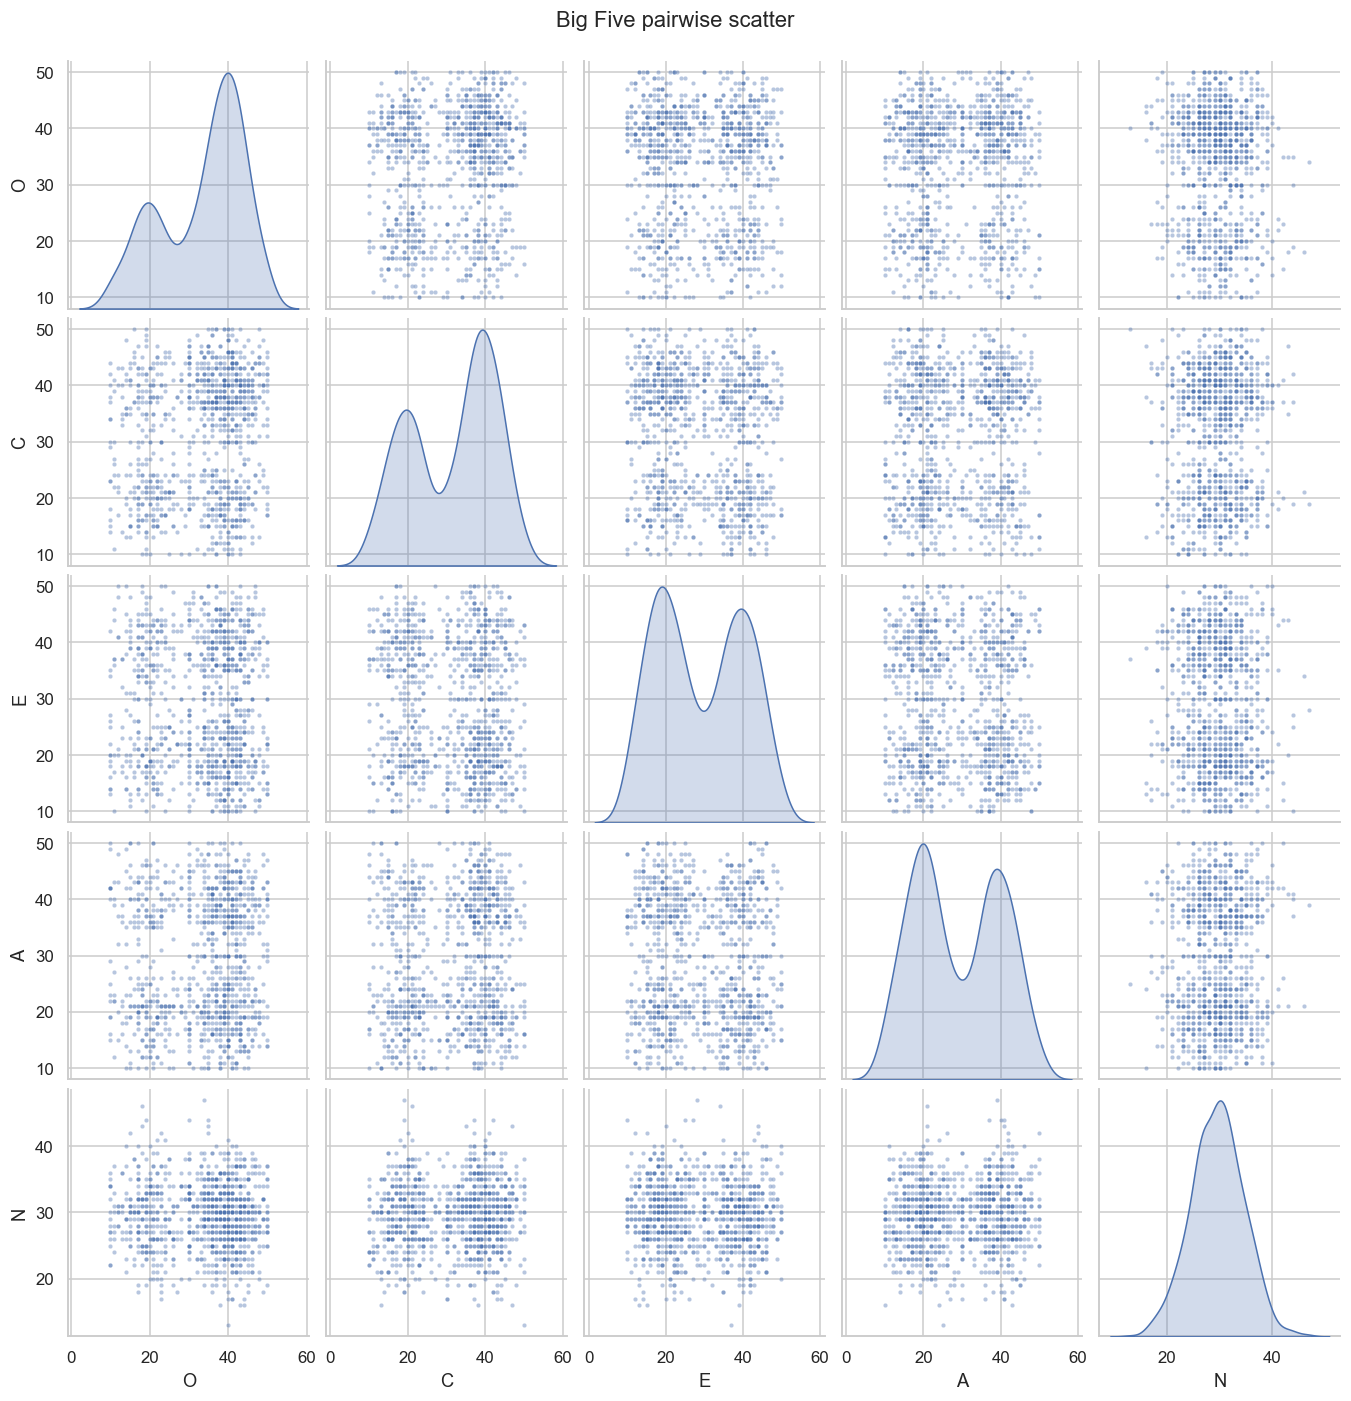

In [17]:
g = sns.pairplot(psych[list('OCEAN')], diag_kind='kde', plot_kws={'s': 8, 'alpha': 0.4})
g.fig.suptitle('Big Five pairwise scatter', y=1.02)
plt.show()

Traits are largely uncorrelated (|r| < 0.1 everywhere) and the pairwise scatters show no visible structure. Each trait carries independent information — Keeping all five as candidate features in Week 2.

## 4. LDAP directory snapshots

LDAP files give role / department / team. They are released monthly to observe membership changes.

In [18]:
ldap_dir = DATA_DIR / 'LDAP'
ldap_files = sorted(ldap_dir.glob('*.csv')) if ldap_dir.exists() else []
len(ldap_files)

18

In [19]:
[p.name for p in ldap_files[:3]], [p.name for p in ldap_files[-3:]]

(['2009-12.csv', '2010-01.csv', '2010-02.csv'],
 ['2011-03.csv', '2011-04.csv', '2011-05.csv'])

In [20]:
ldap_first = pd.read_csv(ldap_files[0]) if ldap_files else pd.DataFrame()
ldap_first.head()

,employee_name,user_id,email,role,business_unit,functional_unit,department,team,supervisor
0,Yvette Vivien Donovan,YVD0093,Yvette.Vivien.Donovan@dtaa.com,MaterialsEngineer,1,2 - ResearchAndEngineering,3 - Engineering,3 - MaterialsEngineering,Alvin Stuart Davenport
1,Troy Alvin Craig,TAC0118,Troy.Alvin.Craig@dtaa.com,Manager,1,3 - Manufacturing,3 - Assembly,NaN,Celeste Cora Spears
2,Eden Jocelyn Mcclain,EJM0952,Eden.Jocelyn.Mcclain@dtaa.com,ProductionLineWorker,1,3 - Manufacturing,3 - Assembly,6 - AssemblyDept,Sawyer Perry Navarro
3,Alexa Emma Wood,AEW0655,Alexa.Emma.Wood@dtaa.com,Technician,1,5 - SalesAndMarketing,3 - FieldService,3 - RegionalFieldService,Robert Melvin Mcfarland
4,Celeste Maris Griffith,CMG0936,Celeste.Maris.Griffith@dtaa.com,ComputerScientist,1,2 - ResearchAndEngineering,2 - SoftwareManagement,6 - Software,Tobias Galvin Robbins


In [21]:
ldap_first.shape, ldap_first.columns.tolist()

((1000, 9),
 ['employee_name',
  'user_id',
  'email',
  'role',
  'business_unit',
  'functional_unit',
  'department',
  'team',
  'supervisor'])

In [ ]:
monthly = []
for p in ldap_files:
    df = pd.read_csv(p, usecols=['user_id'])
    monthly.append({'month': p.stem, 'n_users': df['user_id'].nunique()})
monthly = pd.DataFrame(monthly)
monthly.head()

,month,n_users
0,2009-12,1000
1,2010-01,1000
2,2010-02,994
3,2010-03,992
4,2010-04,987


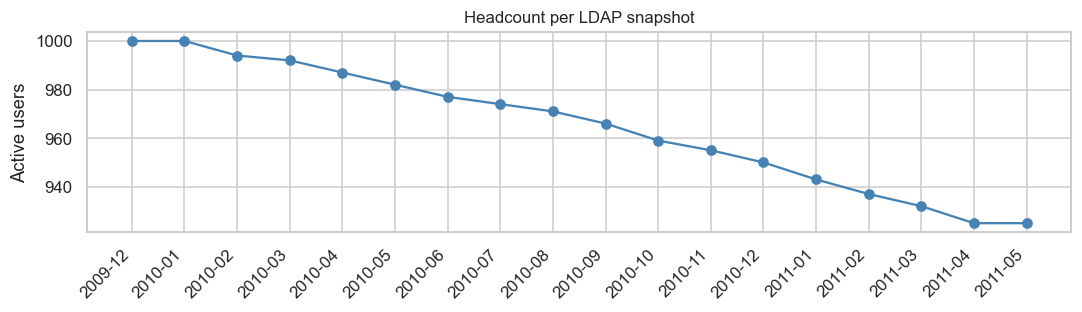

In [23]:
plt.figure(figsize=(10, 3))
plt.plot(monthly['month'], monthly['n_users'], marker='o', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Active users')
plt.title('Headcount per LDAP snapshot')
plt.tight_layout()
plt.show()

In [24]:
# Joiners / leavers between consecutive snapshots
prev = None
churn = []
for p in ldap_files:
    cur = set(pd.read_csv(p, usecols=['user_id'])['user_id'])
    if prev is not None:
        churn.append({'month': p.stem,
                      'joiners': len(cur - prev),
                      'leavers': len(prev - cur)})
    prev = cur
churn = pd.DataFrame(churn)
churn.head()

,month,joiners,leavers
0,2010-01,0,0
1,2010-02,0,6
2,2010-03,0,2
3,2010-04,0,5
4,2010-05,0,5


/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_16128/2148896155.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(churn['month'], rotation=45, ha='right')


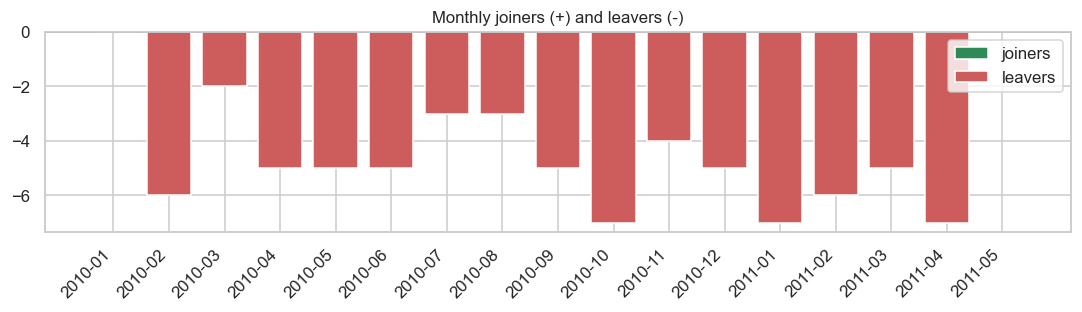

In [25]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(churn['month'], churn['joiners'], label='joiners', color='seagreen')
ax.bar(churn['month'], -churn['leavers'], label='leavers', color='indianred')
ax.set_xticklabels(churn['month'], rotation=45, ha='right')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Monthly joiners (+) and leavers (-)')
ax.legend()
plt.tight_layout()
plt.show()

**Read:** Headcount grows slowly; a handful of joiners and very few leavers per month. We keep the **most recent** LDAP snapshot as the canonical role mapping; tracking role *changes* is revisited in Week 2.

In [26]:
ldap_latest = pd.read_csv(ldap_files[-1])
ldap_latest.head()

,employee_name,user_id,email,role,business_unit,functional_unit,department,team,supervisor
0,Yvette Vivien Donovan,YVD0093,Yvette.Vivien.Donovan@dtaa.com,MaterialsEngineer,1,2 - ResearchAndEngineering,3 - Engineering,3 - MaterialsEngineering,Alvin Stuart Davenport
1,Troy Alvin Craig,TAC0118,Troy.Alvin.Craig@dtaa.com,Manager,1,3 - Manufacturing,3 - Assembly,NaN,Celeste Cora Spears
2,Eden Jocelyn Mcclain,EJM0952,Eden.Jocelyn.Mcclain@dtaa.com,ProductionLineWorker,1,3 - Manufacturing,3 - Assembly,6 - AssemblyDept,Sawyer Perry Navarro
3,Alexa Emma Wood,AEW0655,Alexa.Emma.Wood@dtaa.com,Technician,1,5 - SalesAndMarketing,3 - FieldService,3 - RegionalFieldService,Robert Melvin Mcfarland
4,Celeste Maris Griffith,CMG0936,Celeste.Maris.Griffith@dtaa.com,ComputerScientist,1,2 - ResearchAndEngineering,2 - SoftwareManagement,6 - Software,Tobias Galvin Robbins


In [27]:
ldap_latest.nunique()

employee_name      925
user_id            925
email              925
role                43
business_unit        1
functional_unit      6
department          22
team                38
supervisor          67
dtype: int64

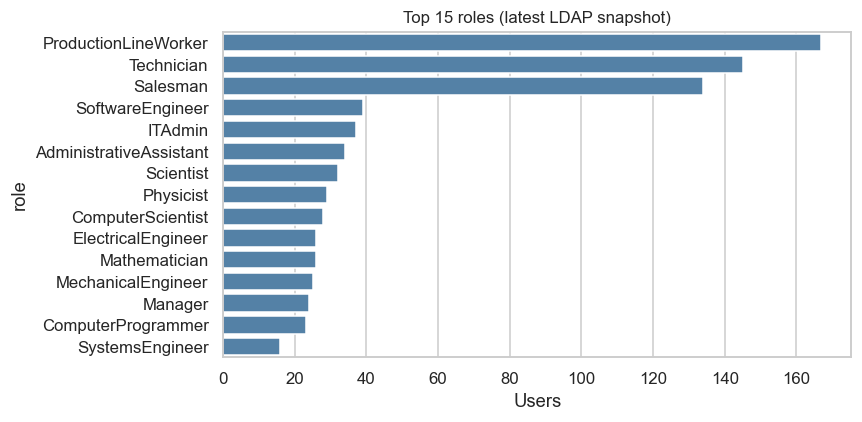

In [29]:
top_roles = ldap_latest['role'].value_counts().head(15)
plt.figure(figsize=(8, 4))
sns.barplot(y=top_roles.index, x=top_roles.values, color='steelblue')
plt.xlabel('Users'); plt.title('Top 15 roles (latest LDAP snapshot)')
plt.tight_layout(); plt.show()

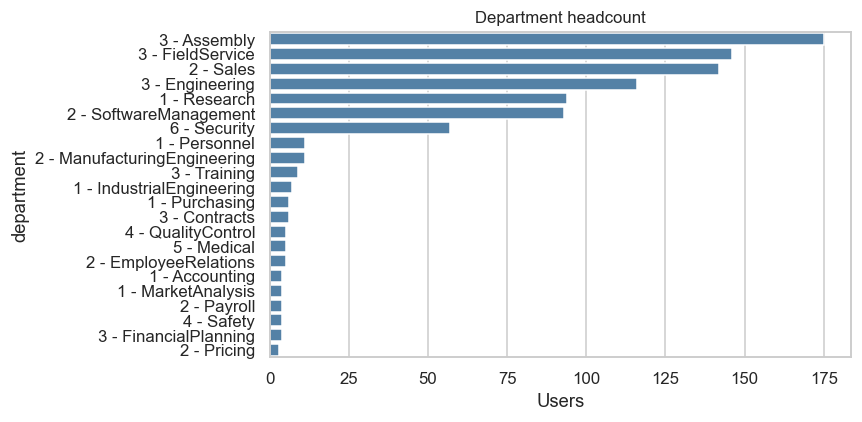

In [30]:
dep = ldap_latest['department'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(y=dep.index, x=dep.values, color='steelblue')
plt.xlabel('Users'); plt.title('Department headcount')
plt.tight_layout(); plt.show()

## 5. Logon events

The primary activity signal. Logon/Logoff timestamps tell us when users are at their workstation.

In [31]:
logon = pd.read_csv(DATA_DIR / 'logon.csv')
logon.shape

(899118, 5)

In [32]:
logon.head()

,id,date,user,pc,activity
0,{X0W9-Q2DW16EI-1074QDVQ},01/02/2010 05:02:50,WCR0044,PC-9174,Logon
1,{C2O4-Z2RH12FQ-9176MUEL},01/02/2010 05:19:09,WCR0044,PC-9174,Logoff
2,{U1J8-P4HX02EV-5327GONH},01/02/2010 06:22:11,WCR0044,PC-5494,Logon
3,{F1N9-G4ZL24LA-8747VGHG},01/02/2010 06:33:00,LRG0155,PC-0450,Logon
4,{Y1Q0-U9BN24NB-1906LMVT},01/02/2010 06:42:00,RHM0148,PC-8152,Logon


In [33]:
logon.dtypes

id          object
date        object
user        object
pc          object
activity    object
dtype: object

In [34]:
logon.isna().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

In [35]:
logon['activity'].value_counts()

activity
Logon     496074
Logoff    403044
Name: count, dtype: int64

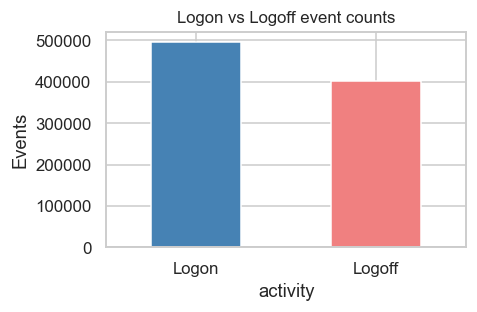

In [ ]:
plt.figure(figsize=(4.5, 3))
logon['activity'].value_counts().plot(kind='bar', color=['steelblue', 'lightcoral'])
plt.title('Logon vs Logoff event counts')
plt.ylabel('Events')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Read:** Logons exceed logoffs by ~93k. This matches the documented behaviour that screen unlocks count as logons but screen locks are not recorded — a working day can have many logons but only one logoff.

In [37]:
logon['date'] = pd.to_datetime(logon['date'])

In [38]:
logon['date'].agg(['min', 'max'])

min   2010-01-02 05:02:50
max   2011-05-17 08:03:46
Name: date, dtype: datetime64[ns]

In [ ]:
logon['hour'] = logon['date'].dt.hour
logon['weekday'] = logon['date'].dt.weekday  # 0=Mon
logon['day'] = logon['date'].dt.normalize()
logon['is_weekend'] = logon['weekday'].isin([5, 6])
logon['is_after_hours'] = (logon['hour'] < 7) | (logon['hour'] >= 19)
logon[['hour', 'weekday', 'is_weekend', 'is_after_hours']].head()

,hour,weekday,is_weekend,is_after_hours
0,5,5,True,True
1,5,5,True,True
2,6,5,True,True
3,6,5,True,True
4,6,5,True,True


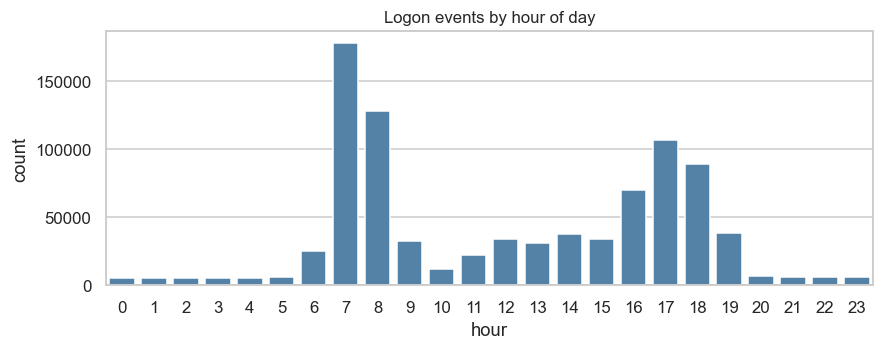

In [ ]:
plt.figure(figsize=(9, 3))
sns.countplot(x='hour', data=logon, color='steelblue')
plt.title('Logon events by hour of day')
plt.show()

**Read:** Strong daytime peak roughly 07:00–18:00. A non-trivial tail outside business hours — this tail is what our risk model will lean on.

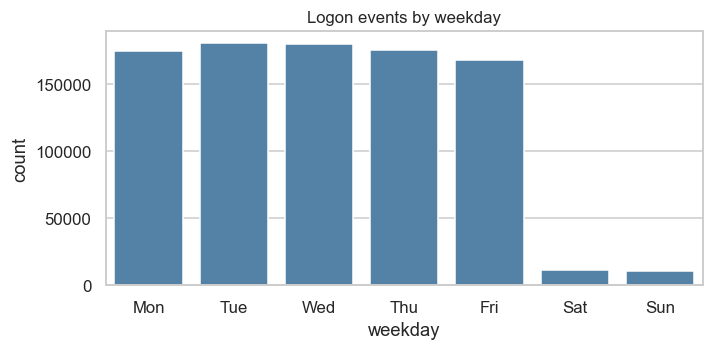

In [41]:
plt.figure(figsize=(7, 3))
sns.countplot(x='weekday', data=logon, order=range(7), color='steelblue')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Logon events by weekday')
plt.show()

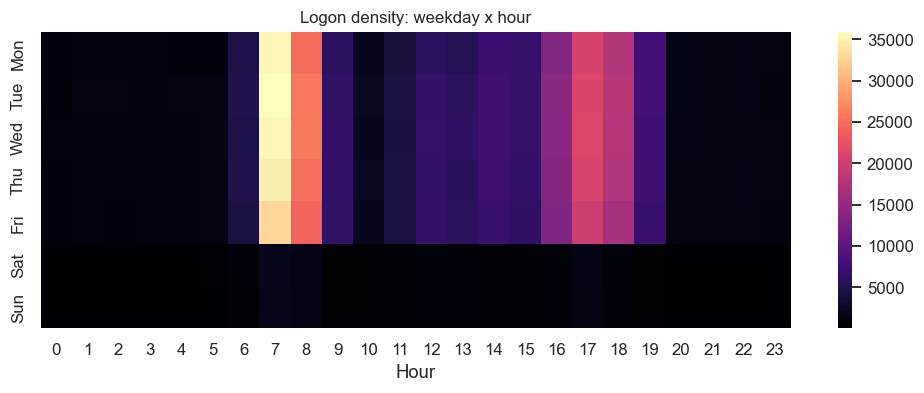

In [42]:
heat = (logon.groupby(['weekday', 'hour']).size().unstack(fill_value=0))
plt.figure(figsize=(11, 3.5))
sns.heatmap(heat, cmap='magma',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.xlabel('Hour'); plt.ylabel('')
plt.title('Logon density: weekday x hour')
plt.show()

**Read:** Heatmap confirms the Mon–Fri / 07–18 working block. Weekend activity is sparse but not zero. After-hours weekday logons form a thin band — exactly what the unsupervised detectors in Week 3 should latch onto.

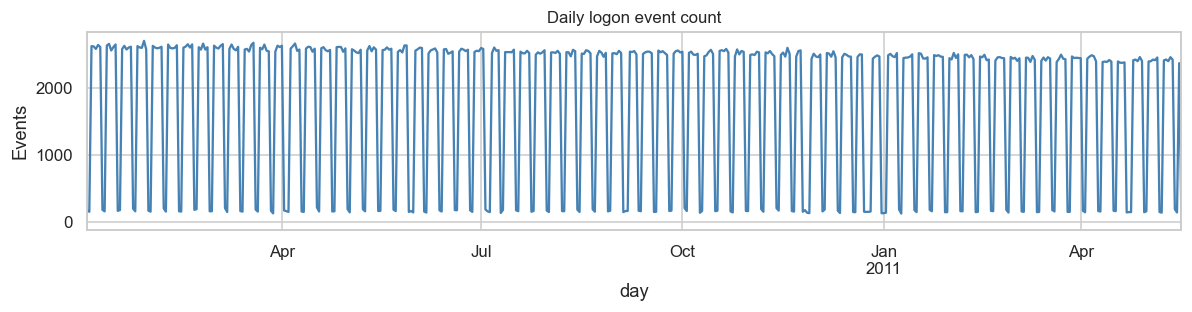

In [43]:
daily = logon.groupby('day').size()
plt.figure(figsize=(11, 3))
daily.plot(color='steelblue')
plt.title('Daily logon event count'); plt.ylabel('Events')
plt.tight_layout()
plt.show()

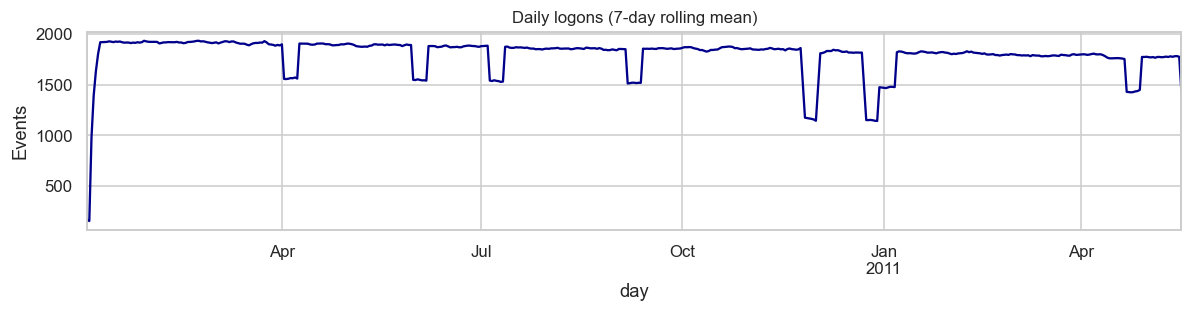

In [44]:
# Rolling 7-day mean to smooth out weekend dips
plt.figure(figsize=(11, 3))
daily.rolling(7, min_periods=1).mean().plot(color='darkblue')
plt.title('Daily logons (7-day rolling mean)'); plt.ylabel('Events')
plt.tight_layout()
plt.show()

**Read:** Daily volume is stable across the period with the expected weekly seasonality. No obvious data-quality cliffs (no missing weeks, no enormous spikes). Safe to treat the time series as continuous.

In [45]:
user_logon_counts = logon.groupby('user').size()
user_logon_counts.describe().round(1)

count    1000.0
mean      899.1
std       464.7
min        56.0
25%       692.0
50%       692.0
75%       974.0
max      3995.0
dtype: float64

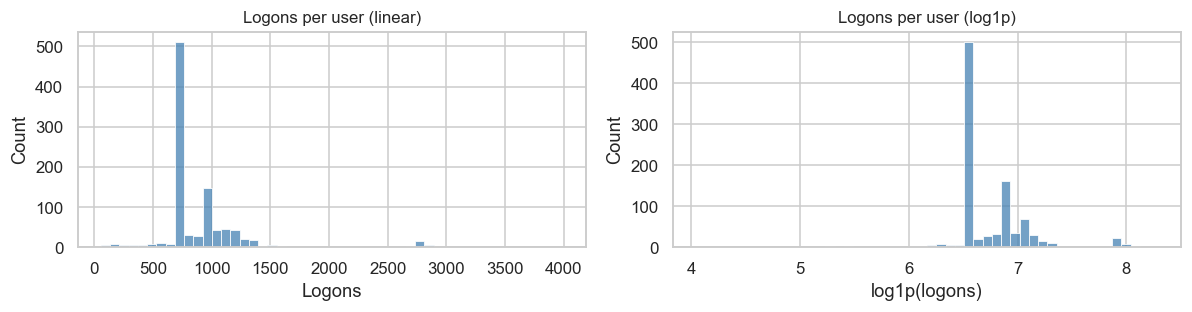

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(user_logon_counts, bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('Logons per user (linear)')
axes[0].set_xlabel('Logons')
sns.histplot(np.log1p(user_logon_counts), bins=50, color='steelblue', ax=axes[1])
axes[1].set_title('Logons per user (log1p)')
axes[1].set_xlabel('log1p(logons)')
plt.tight_layout()
plt.show()

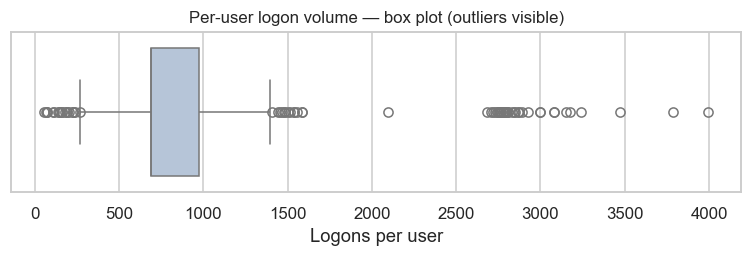

In [47]:
plt.figure(figsize=(7, 2.5))
sns.boxplot(x=user_logon_counts, color='lightsteelblue')
plt.xlabel('Logons per user')
plt.title('Per-user logon volume — box plot (outliers visible)')
plt.tight_layout()
plt.show()

**Read:** Most users sit around 600–1000 logons; a long right tail of heavy users (>2000). Log scale collapses the tail and shows a much cleaner near-normal shape — we will likely log-transform intensity features in Week 2.

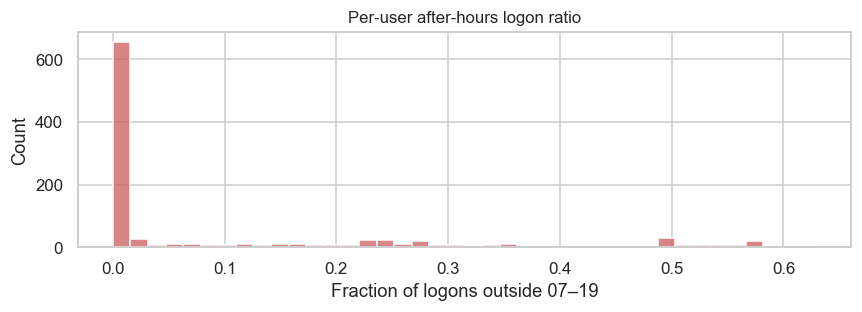

In [48]:
# Per-user after-hours ratio at this stage (rough)
after_hours_ratio = (logon[logon['is_after_hours']].groupby('user').size()
                     / logon.groupby('user').size()).fillna(0)
plt.figure(figsize=(8, 3))
sns.histplot(after_hours_ratio, bins=40, color='indianred')
plt.title('Per-user after-hours logon ratio')
plt.xlabel('Fraction of logons outside 07–19')
plt.tight_layout()
plt.show()

**Read:** The majority of users have a near-zero after-hours ratio, but a clear group exists with 10–40% after-hours activity. These users are the natural candidates the unsupervised models will flag in Week 3.

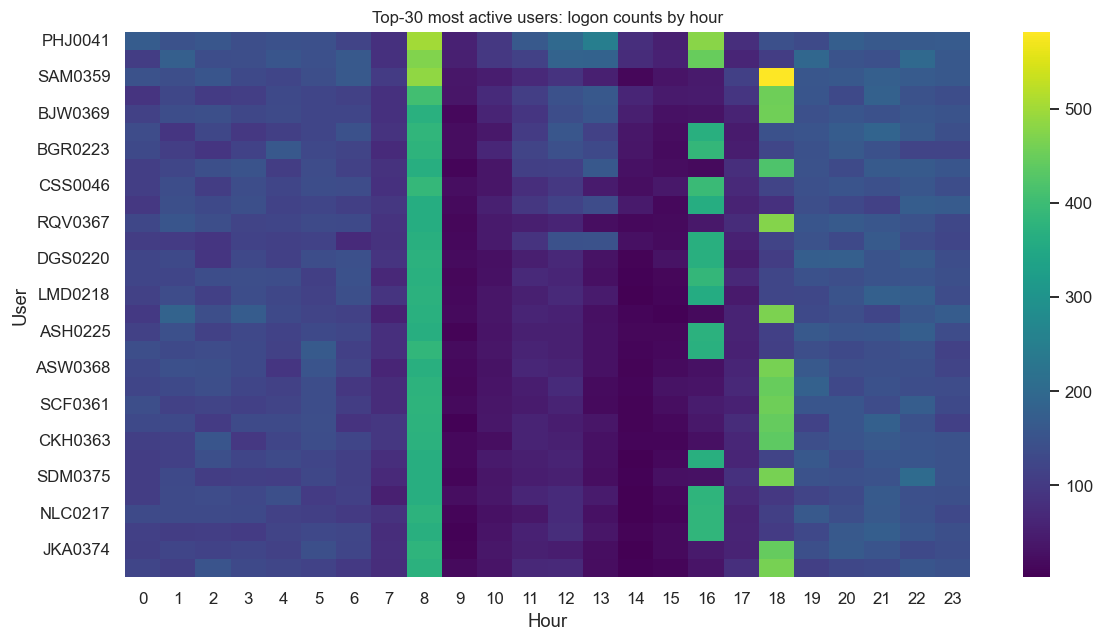

In [49]:
# Heatmap: top-30 most active users x hour
top_users = user_logon_counts.sort_values(ascending=False).head(30).index
heat_user = (logon[logon['user'].isin(top_users)]
             .groupby(['user', 'hour']).size().unstack(fill_value=0)
             .reindex(top_users))
plt.figure(figsize=(11, 6))
sns.heatmap(heat_user, cmap='viridis')
plt.title('Top-30 most active users: logon counts by hour')
plt.xlabel('Hour')
plt.ylabel('User')
plt.tight_layout()
plt.show()

**Read:** Even among the top-30 users you can see heterogeneous schedules — some peak around 08:00, others around 11:00–13:00. This per-user variability is exactly why aggregate-only features are not enough; we need per-user normalised features.

## 6. Device (USB) events

In [50]:
device = pd.read_csv(DATA_DIR / 'device.csv')
device.shape

(437168, 5)

In [51]:
device.head()

,id,date,user,pc,activity
0,{P1I9-X2UT34LR-6485PDJX},01/02/2010 05:15:32,WCR0044,PC-9174,Connect
1,{S2D2-V1NT65KD-8108KBSZ},01/02/2010 05:17:09,WCR0044,PC-9174,Disconnect
2,{G5Y9-L4GP40WG-0372GEOX},01/02/2010 06:39:10,WCR0044,PC-5494,Connect
3,{A4Q5-A1FR45TY-9562ISJI},01/02/2010 06:40:30,WCR0044,PC-5494,Disconnect
4,{M9Q0-O7UM21OB-5937NRWH},01/02/2010 07:02:33,BHV0556,PC-6254,Connect


In [52]:
device['activity'].value_counts()

activity
Connect       219236
Disconnect    217932
Name: count, dtype: int64

In [ ]:
device['date'] = pd.to_datetime(device['date'])
device['hour'] = device['date'].dt.hour
device['weekday'] = device['date'].dt.weekday
device['day'] = device['date'].dt.normalize()
device['is_after_hours'] = (device['hour'] < 7) | (device['hour'] >= 19)
device.head()

,id,date,user,pc,activity,hour,weekday,day,is_after_hours
0,{P1I9-X2UT34LR-6485PDJX},2010-01-02 05:15:32,WCR0044,PC-9174,Connect,5,5,2010-01-02,True
1,{S2D2-V1NT65KD-8108KBSZ},2010-01-02 05:17:09,WCR0044,PC-9174,Disconnect,5,5,2010-01-02,True
2,{G5Y9-L4GP40WG-0372GEOX},2010-01-02 06:39:10,WCR0044,PC-5494,Connect,6,5,2010-01-02,True
3,{A4Q5-A1FR45TY-9562ISJI},2010-01-02 06:40:30,WCR0044,PC-5494,Disconnect,6,5,2010-01-02,True
4,{M9Q0-O7UM21OB-5937NRWH},2010-01-02 07:02:33,BHV0556,PC-6254,Connect,7,5,2010-01-02,False


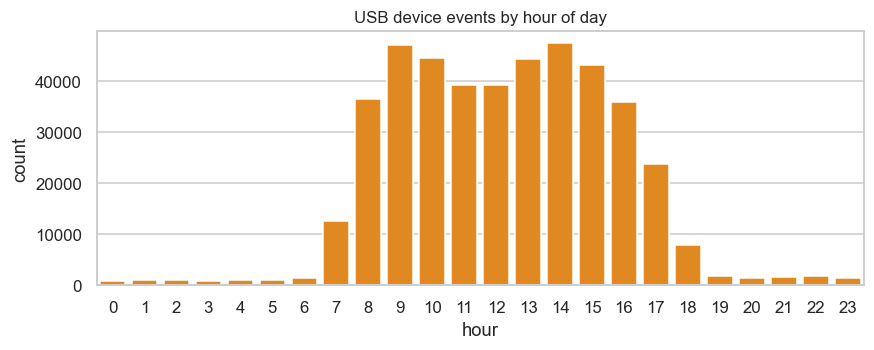

In [54]:
plt.figure(figsize=(9, 3))
sns.countplot(x='hour', data=device, color='darkorange')
plt.title('USB device events by hour of day')
plt.show()

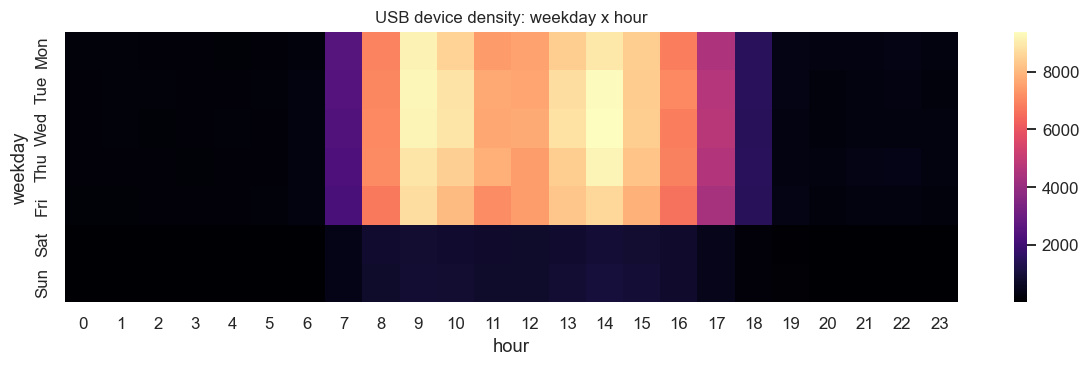

In [55]:
heat_dev = device.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
plt.figure(figsize=(11, 3.5))
sns.heatmap(heat_dev, cmap='magma',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('USB device density: weekday x hour')
plt.tight_layout()
plt.show()

**Read:** Device usage tracks the work-day curve like logons but with a heavier early-morning tail. CERT documentation specifically calls out **after-hours USB usage** as a high-signal indicator — confirmed visually.

In [56]:
dev_users = device['user'].nunique()
total_users = psych['user_id'].nunique()
dev_users, total_users, round(dev_users / total_users, 3)

(193, 1000, 0.193)

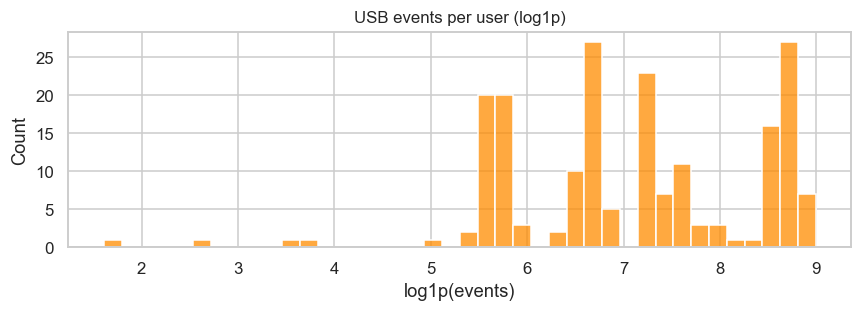

In [57]:
user_dev_counts = device.groupby('user').size()
plt.figure(figsize=(8, 3))
sns.histplot(np.log1p(user_dev_counts), bins=40, color='darkorange')
plt.title('USB events per user (log1p)')
plt.xlabel('log1p(events)')
plt.tight_layout()
plt.show()

**Read:** Only a fraction of the user base shows any device activity. For users with zero device events we will fill USB features with 0 (interpretable as 'no observed activity'), not NaN.

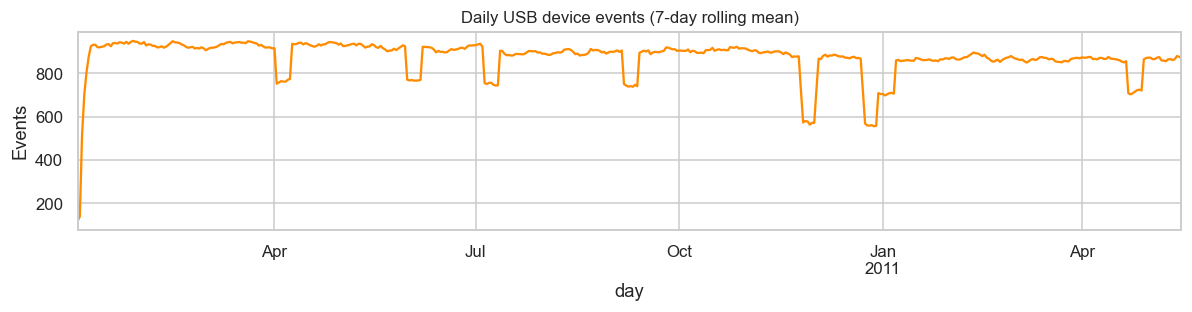

In [58]:
# Daily device volume
plt.figure(figsize=(11, 3))
device.groupby('day').size().rolling(7, min_periods=1).mean().plot(color='darkorange')
plt.title('Daily USB device events (7-day rolling mean)')
plt.ylabel('Events')
plt.tight_layout()
plt.show()

## 7. File operations (removable media)

In [59]:
file = pd.read_csv(DATA_DIR / 'file.csv')
file.shape

(414556, 6)

In [60]:
file.head()

,id,date,user,pc,filename,content
0,{Q5M2-N0JR22AA-1727ALDU},01/02/2010 05:15:35,WCR0044,PC-9174,KQTA0DRL.pdf,25-50-44-46-2D laugh statements references pla...
1,{O2W1-I9JA58XQ-7973YYAK},01/02/2010 05:16:04,WCR0044,PC-9174,PS5NPZPV.doc,D0-CF-11-E0-A1-B1-1A-E1 identifies new maxi do...
2,{O0T0-H0OD25UT-0238OGNR},01/02/2010 05:16:25,WCR0044,PC-9174,VJX6WCC9.doc,D0-CF-11-E0-A1-B1-1A-E1 emotionally antagonist...
3,{Y5P3-S3DI98OH-7978PRAW},01/02/2010 05:16:28,WCR0044,PC-9174,726ERRX7.doc,D0-CF-11-E0-A1-B1-1A-E1 park central personal ...
4,{C5T9-R4OO02RR-0266RBKQ},01/02/2010 05:16:29,WCR0044,PC-9174,38FJLPW2.jpg,FF-D8


In [61]:
file.dtypes

id          object
date        object
user        object
pc          object
filename    object
content     object
dtype: object

In [ ]:
file['date'] = pd.to_datetime(file['date'])
file['hour'] = file['date'].dt.hour
file['weekday'] = file['date'].dt.weekday
file['day'] = file['date'].dt.normalize()
file['is_after_hours'] = (file['hour'] < 7) | (file['hour'] >= 19)

In [ ]:
file['ext'] = file['filename'].str.extract(r'\.([A-Za-z0-9]+)$')[0].str.lower()
file['ext'].value_counts().head(10)

ext
doc    265501
pdf     82437
txt     21384
jpg     21313
zip     21136
exe      2785
Name: count, dtype: int64

**Read:** Extensions are concentrated in a handful of types (`doc`, `pdf`, `jpg`, …). Useful as a categorical breakdown but probably too coarse to be a strong feature on its own. We will likely aggregate to *document vs media vs executable* in Week 2.

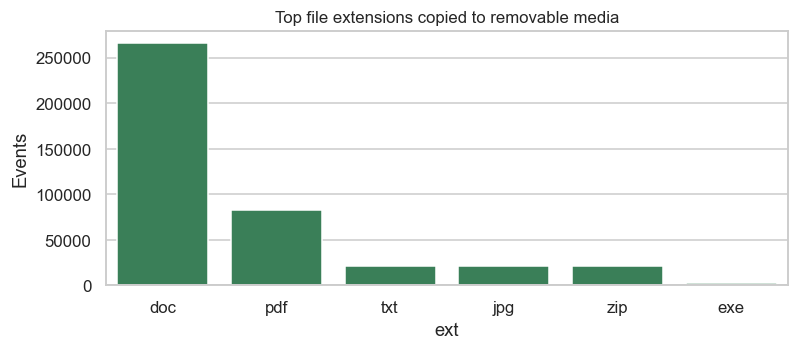

In [64]:
plt.figure(figsize=(8, 3))
top_ext = file['ext'].value_counts().head(8)
sns.barplot(x=top_ext.index, y=top_ext.values, color='seagreen')
plt.title('Top file extensions copied to removable media')
plt.ylabel('Events')
plt.show()

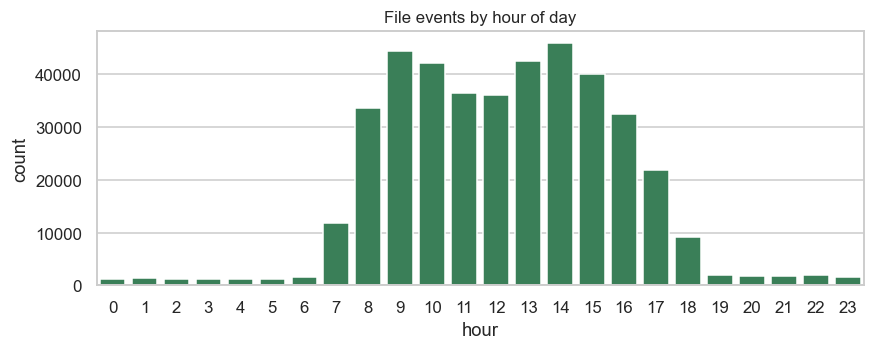

In [65]:
plt.figure(figsize=(9, 3))
sns.countplot(x='hour', data=file, color='seagreen')
plt.title('File events by hour of day')
plt.show()

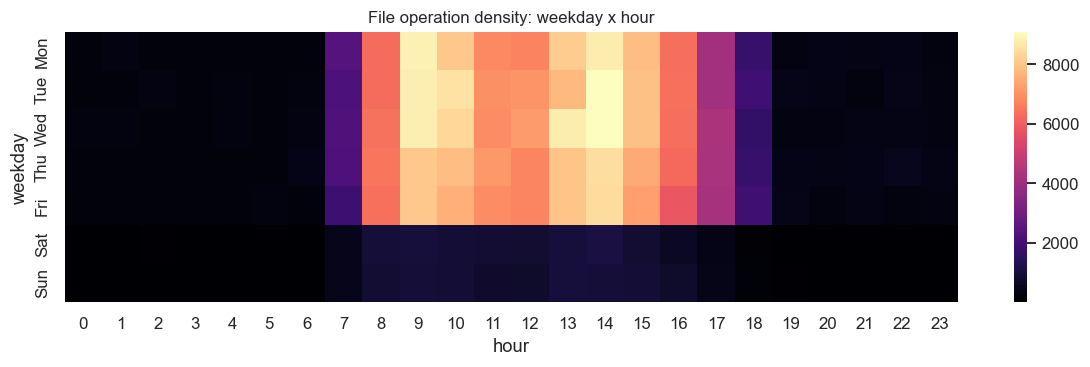

In [ ]:
heat_file = file.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
plt.figure(figsize=(11, 3.5))
sns.heatmap(heat_file, cmap='magma',
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('File operation density: weekday x hour')
plt.tight_layout()
plt.show()

In [67]:
# After-hours fraction by file extension — is any ext disproportionately after-hours?
ah_by_ext = (file.groupby('ext')['is_after_hours']
             .agg(['mean', 'count'])
             .query('count > 1000')
             .sort_values('mean', ascending=False)
             .head(10))
ah_by_ext

,mean,count
ext,,
exe,0.046679,2785
pdf,0.043876,82437
zip,0.043717,21136
doc,0.043638,265501
jpg,0.043166,21313
txt,0.043070,21384


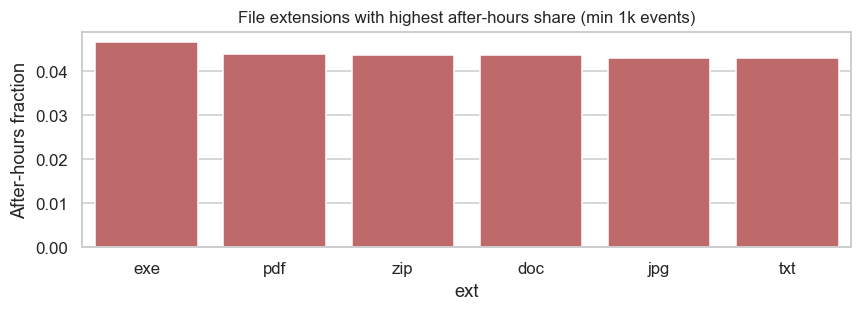

In [68]:
plt.figure(figsize=(8, 3))
sns.barplot(x=ah_by_ext.index, y=ah_by_ext['mean'], color='indianred')
plt.ylabel('After-hours fraction')
plt.title('File extensions with highest after-hours share (min 1k events)')
plt.tight_layout()
plt.show()

**Read:** Some extensions are disproportionately written outside business hours. We will keep extension-level after-hours fractions in mind when engineering Week-2 features.

## 8. Email and HTTP — chunked sampling

These are too large to load fully. We sample by reading in chunks and keeping a fixed fraction of rows. The goal here is only to characterise schema and per-user volume — full per-user aggregates will be re-computed in Week 2 using a streaming pass.


In [69]:
def sample_csv(path, frac=0.01, chunksize=500_000, seed=42):
    rng = np.random.default_rng(seed)
    parts = []
    for chunk in pd.read_csv(path, chunksize=chunksize):
        mask = rng.random(len(chunk)) < frac
        parts.append(chunk.loc[mask])
    return pd.concat(parts, ignore_index=True)

In [70]:
email_sample = sample_csv(DATA_DIR / 'email.csv', frac=0.01)
email_sample.shape

(27172, 11)

In [71]:
email_sample.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{N9X9-G0NQ22VM-8291DWRY},01/02/2010 08:56:18,WCR0044,PC-3274,Leroy.Mufutau.Durham@dtaa.com;Prescott.Wyatt.S...,Murphy.Flynn.Ryan@dtaa.com,William.Casey.Ramsey@dtaa.com,William.Casey.Ramsey@dtaa.com,46340,1,established though required days cloudy 1848 i...
1,{U1B4-V5RY48SV-7465AOVL},01/02/2010 17:21:30,NEB0688,PC-7227,Colton.Aaron.Burch@dtaa.com;Larissa.Phyllis.Hu...,NaN,Nicolas.Elvis.Bowers@dtaa.com,Nicolas.Elvis.Bowers@dtaa.com,35700,1,release reveals adaptation klooques fourth rel...
2,{W3K6-B1TL05MB-0795ZPDZ},01/03/2010 10:09:55,SPW0142,PC-1550,Ila.Aphrodite.Trujillo@dtaa.com,Skyler.Paula.Whitehead@dtaa.com,NaN,Skyler.Paula.Whitehead@dtaa.com,31744,0,competition after announced before beating for...
3,{S3N4-I4ET18DM-2976WVZN},01/03/2010 11:41:14,NAY0604,PC-0218,Pruitt-Kareem@gmail.com,NaN,NaN,Yates-Neil@hotmail.com,27062,2,added york ive goth thus deal they poignant ne...
4,{V5K3-J1EW01LO-0273ZLTO},01/03/2010 13:04:38,BHV0556,PC-6254,Macaulay.Lance.Blake@dtaa.com;Jaime.Eugenia.Ca...,NaN,NaN,Byron.Hiram.Vega@dtaa.com,47435,0,m won closure tight lighting mills character a...


In [72]:
email_sample.dtypes

id             object
date           object
user           object
pc             object
to             object
cc             object
bcc            object
from           object
size            int64
attachments     int64
content        object
dtype: object

In [73]:
email_sample.isna().mean().round(3)

id             0.000
date           0.000
user           0.000
pc             0.000
to             0.000
cc             0.616
bcc            0.841
from           0.000
size           0.000
attachments    0.000
content        0.000
dtype: float64

**Read:** `bcc` / `cc` are sparsely populated — most messages have no CC/BCC. Recipient counts will be a more reliable feature than CC/BCC flags alone.

In [74]:
email_sample['date'] = pd.to_datetime(email_sample['date'])
email_sample['hour'] = email_sample['date'].dt.hour
email_sample['weekday'] = email_sample['date'].dt.weekday

/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_16128/4021110436.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])


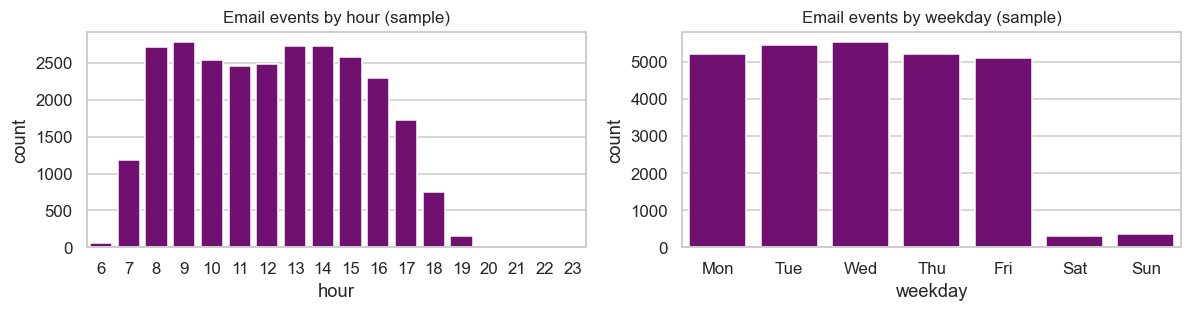

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.countplot(x='hour', data=email_sample, color='purple', ax=axes[0])
axes[0].set_title('Email events by hour (sample)')
sns.countplot(x='weekday', data=email_sample, order=range(7), color='purple', ax=axes[1])
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Email events by weekday (sample)')
plt.tight_layout()
plt.show()

In [76]:
def n_external(row, internal='dtaa.com'):
    rec = str(row).split(';')
    return sum(internal not in r for r in rec if r)
email_sample['n_to'] = email_sample['to'].fillna('').apply(lambda s: len([x for x in s.split(';') if x]))
email_sample['n_external_to'] = email_sample['to'].fillna('').apply(n_external)
email_sample[['n_to', 'n_external_to']].describe().round(2)

,n_to,n_external_to
count,27172.00,27172.00
mean,1.64,0.68
std,0.93,0.95
min,1.00,0.00
25%,1.00,0.00
50%,1.00,0.00
75%,2.00,1.00
max,5.00,5.00


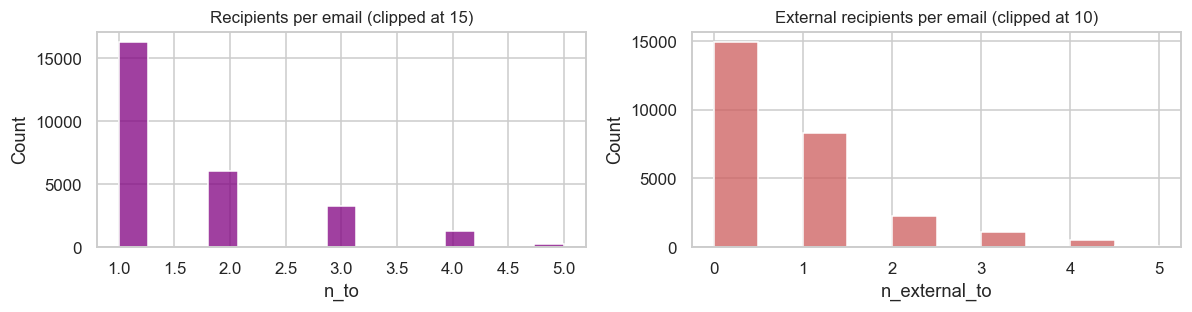

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(email_sample['n_to'].clip(upper=15), bins=15, color='purple', ax=axes[0])
axes[0].set_title('Recipients per email (clipped at 15)')
sns.histplot(email_sample['n_external_to'].clip(upper=10), bins=10, color='indianred', ax=axes[1])
axes[1].set_title('External recipients per email (clipped at 10)')
plt.tight_layout()
plt.show()

**Read:** Most emails go to 1–2 recipients; external recipients are present in a meaningful slice of traffic. External recipient count is a strong candidate exfiltration feature.

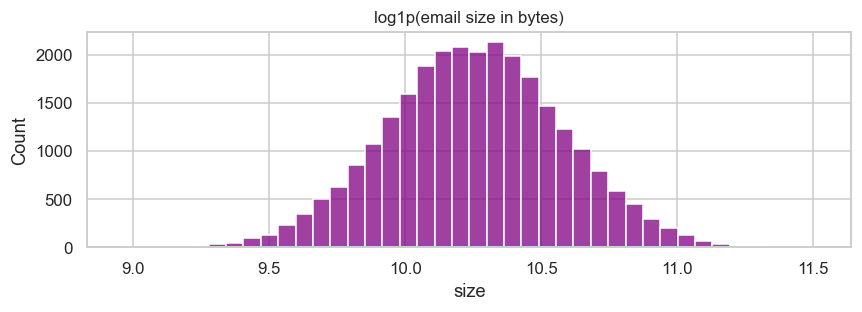

In [78]:
plt.figure(figsize=(8, 3))
sns.histplot(np.log1p(email_sample['size']), bins=40, color='purple')
plt.title('log1p(email size in bytes)')
plt.tight_layout()
plt.show()

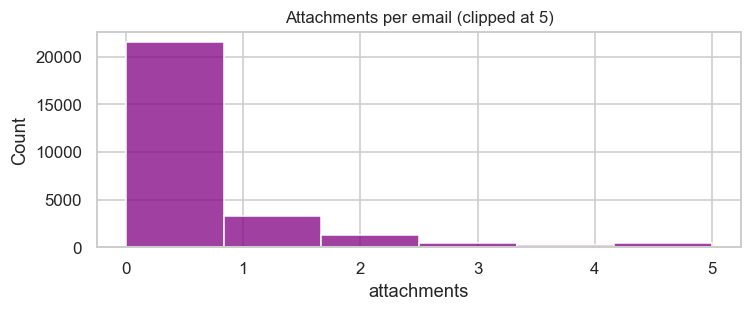

In [79]:
att = email_sample['attachments'].fillna(0)
plt.figure(figsize=(7, 3))
sns.histplot(att.clip(upper=5), bins=6, color='purple')
plt.title('Attachments per email (clipped at 5)')
plt.tight_layout()
plt.show()

In [80]:
http_sample = sample_csv(DATA_DIR / 'http.csv', frac=0.001, chunksize=1_000_000)
http_sample.shape

(29463, 6)

In [81]:
http_sample.head()

,id,date,user,pc,url,content
0,{O1R4-V1AB91WA-8811SPBB},01/02/2010 09:47:10,WCR0044,PC-3274,http://zap2it.com/Midshipman/unsws/ernyrfgngrf...,congressman build headwaters turned expected i...
1,{D4L3-G7EL87VR-9464PQYF},01/02/2010 11:17:06,SAT0503,PC-6091,http://hilton.com/Peter_Heywood/heywoods/zlfgr...,took explanation servants great before propose...
2,{Z0K3-J7GS57ET-1597BINM},01/02/2010 14:09:08,KAH0848,PC-7315,http://discovery.com/Ian_Johnson_cricketer/art...,heraclea participated conquest are refuge offe...
3,{F7E4-A0MM71QX-5896RXEZ},01/02/2010 14:42:08,SAM0359,PC-5281,http://bbc.co.uk/Hurricane_Gordon_2006/candiei...,re described success 4 circuit 13th prevented ...
4,{H1Y1-H1DI12RU-0765RGWH},01/02/2010 15:21:15,BHV0556,PC-6254,http://bizjournals.com/Canadian_federal_electi...,ocean john do hits ecclesiastical route ford v...


In [82]:
http_sample.dtypes

id         object
date       object
user       object
pc         object
url        object
content    object
dtype: object

In [83]:
http_sample['date'] = pd.to_datetime(http_sample['date'])
http_sample['hour'] = http_sample['date'].dt.hour
http_sample['weekday'] = http_sample['date'].dt.weekday

/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_16128/293610478.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])


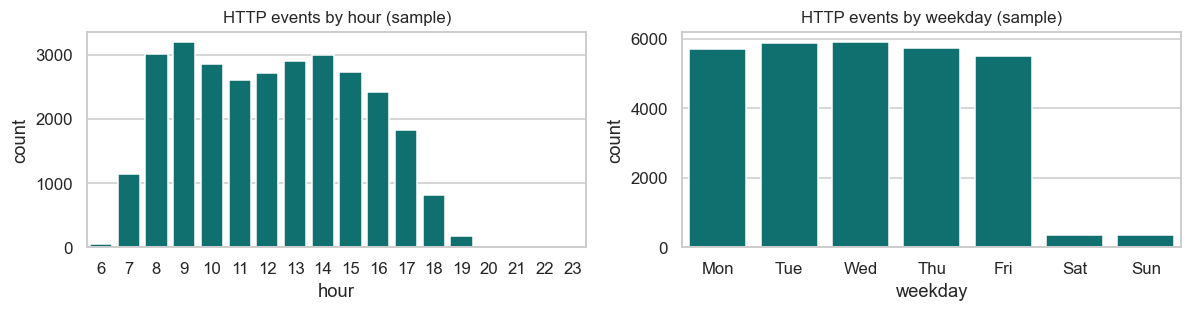

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.countplot(x='hour', data=http_sample, color='teal', ax=axes[0])
axes[0].set_title('HTTP events by hour (sample)')
sns.countplot(x='weekday', data=http_sample, order=range(7), color='teal', ax=axes[1])
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('HTTP events by weekday (sample)')
plt.tight_layout()
plt.show()

In [85]:
http_sample['domain'] = (http_sample['url']
                         .str.replace(r'^https?://', '', regex=True)
                         .str.split('/').str[0]
                         .str.lower())
top_dom = http_sample['domain'].value_counts().head(15)
top_dom

domain
nfl.com             709
linkedin.com        524
inbox.com           514
hilton.com          505
mediafire.com       476
outbrain.com        472
shareasale.com      440
eonline.com         426
wellsfargo.com      419
theblaze.com        405
conduit.com         387
vistaprint.com      382
digitalpoint.com    329
imdb.com            325
sidereel.com        304
Name: count, dtype: int64

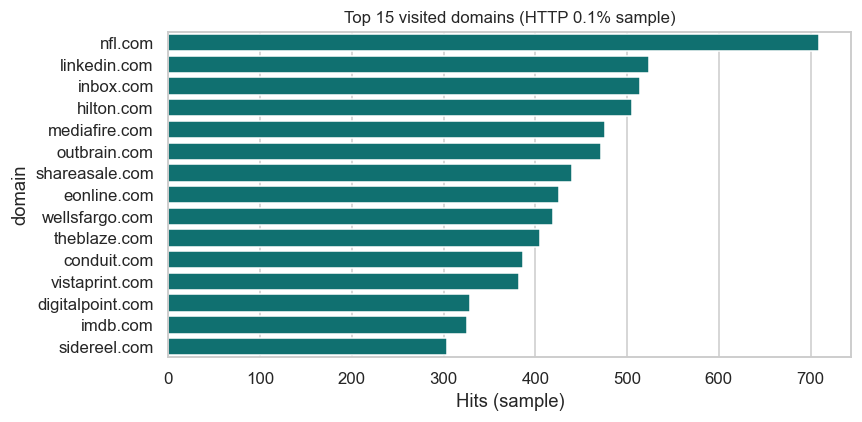

In [86]:
plt.figure(figsize=(8, 4))
sns.barplot(y=top_dom.index, x=top_dom.values, color='teal')
plt.xlabel('Hits (sample)')
plt.title('Top 15 visited domains (HTTP 0.1% sample)')
plt.tight_layout()
plt.show()

**Read:** A small set of high-frequency domains dominate. Unique-domain count per user is therefore likely a useful diversity feature; rare-domain visits are a potential anomaly signal.

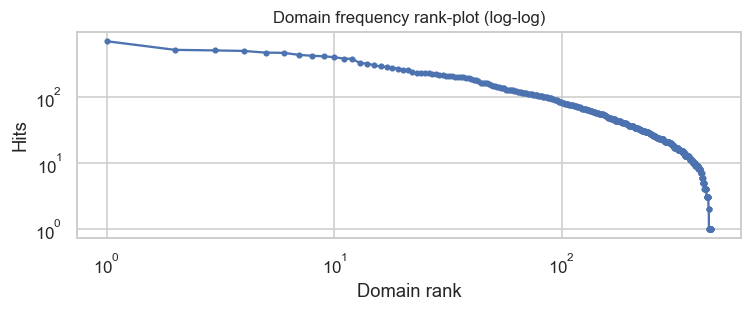

In [87]:
# Domain frequency distribution — Zipf-like?
counts = http_sample['domain'].value_counts().values
plt.figure(figsize=(7, 3))
plt.loglog(range(1, len(counts) + 1), counts, marker='.')
plt.xlabel('Domain rank'); plt.ylabel('Hits')
plt.title('Domain frequency rank-plot (log-log)')
plt.tight_layout()
plt.show()

**Read:** Roughly straight on log-log — consistent with a Zipf-like distribution. Tail-domain visits will be rare but distinctive features.

## 9. Cross-modality user coverage

Not every user appears in every modality. We need to know this before joining.

In [93]:
user_ids = psych['user_id'].values
coverage = pd.DataFrame({
    'logon':  np.isin(user_ids, logon['user'].unique()).astype(int),
    'device': np.isin(user_ids, device['user'].unique()).astype(int),
    'file':   np.isin(user_ids, file['user'].unique()).astype(int),
    'email':  np.isin(user_ids, email_sample['user'].unique()).astype(int),
    'http':   np.isin(user_ids, http_sample['user'].unique()).astype(int),
}, index=user_ids)
coverage.mean().round(3)


logon     1.000
device    0.193
file      0.193
email     0.992
http      0.993
dtype: float64

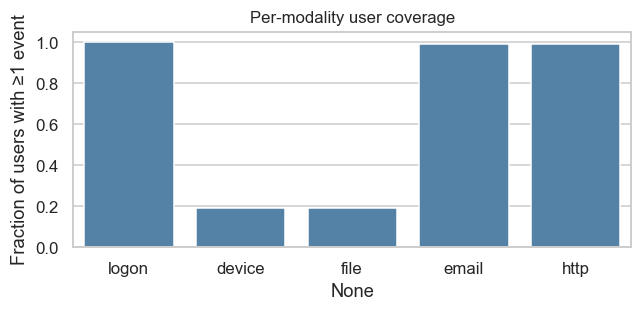

In [94]:
plt.figure(figsize=(6, 3))
sns.barplot(x=coverage.columns, y=coverage.mean().values, color='steelblue')
plt.ylabel('Fraction of users with ≥1 event')
plt.title('Per-modality user coverage')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

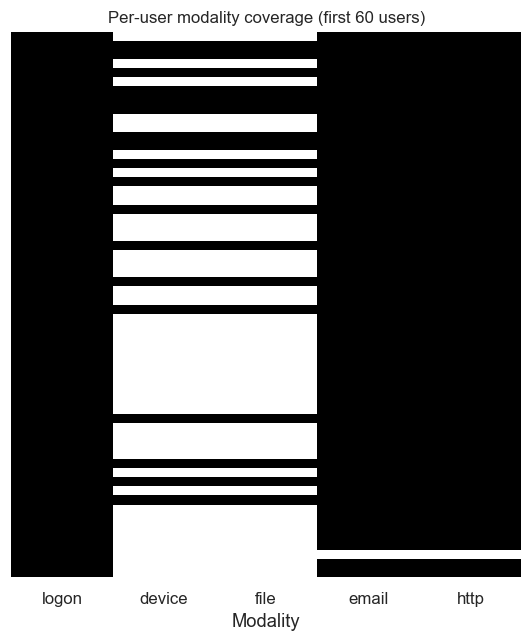

In [95]:
plt.figure(figsize=(5, 6))
sns.heatmap(coverage.head(60).astype(int), cmap='Greys',
            cbar=False, yticklabels=False)
plt.title('Per-user modality coverage (first 60 users)')
plt.xlabel('Modality')
plt.tight_layout()
plt.show()

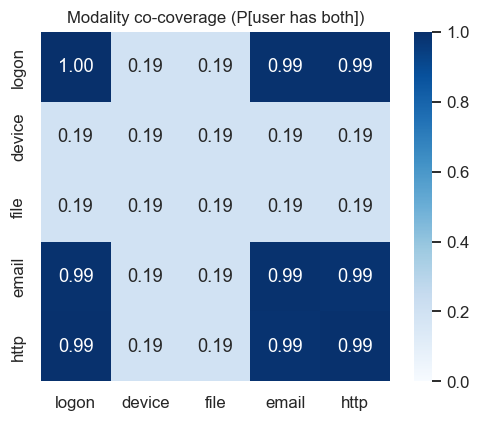

In [96]:
# Co-occurrence matrix between modalities
cooc = coverage.astype(int).T.dot(coverage.astype(int)) / len(coverage)
plt.figure(figsize=(5, 4))
sns.heatmap(cooc, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True)
plt.title('Modality co-coverage (P[user has both])')
plt.tight_layout()
plt.show()

**Read:** All 1000 users have psychometric + logon coverage. Device, file, email, http coverage is partial — for users absent from a modality, Week 2 features will be filled with 0 (interpretable as 'no observed activity').

## 10. Cross-modality activity correlation

Does a user who logs on a lot also generate a lot of file / device / email events?

In [97]:
act = pd.DataFrame({
    'logon_n':  logon.groupby('user').size(),
    'device_n': device.groupby('user').size(),
    'file_n':   file.groupby('user').size(),
    'email_n':  email_sample.groupby('user').size(),
    'http_n':   http_sample.groupby('user').size(),
}).fillna(0)
act.describe().round(1)


,logon_n,device_n,file_n,email_n,http_n
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,899.1,437.2,414.6,27.2,29.5
std,464.7,1362.0,1462.7,19.5,21.2
min,56.0,0.0,0.0,0.0,0.0
25%,692.0,0.0,0.0,9.0,9.0
50%,692.0,0.0,0.0,28.0,32.0
75%,974.0,0.0,0.0,40.0,42.0
max,3995.0,8054.0,11546.0,129.0,153.0


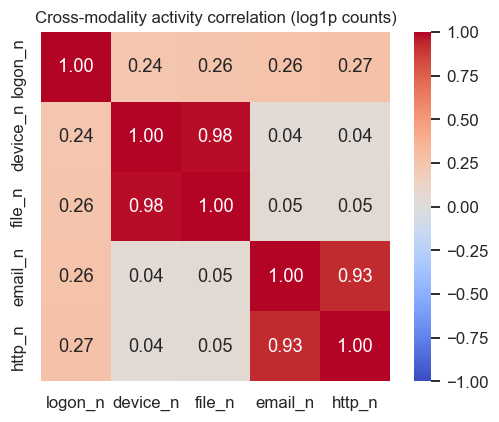

In [98]:
plt.figure(figsize=(5, 4))
sns.heatmap(np.log1p(act).corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Cross-modality activity correlation (log1p counts)')
plt.tight_layout()
plt.show()

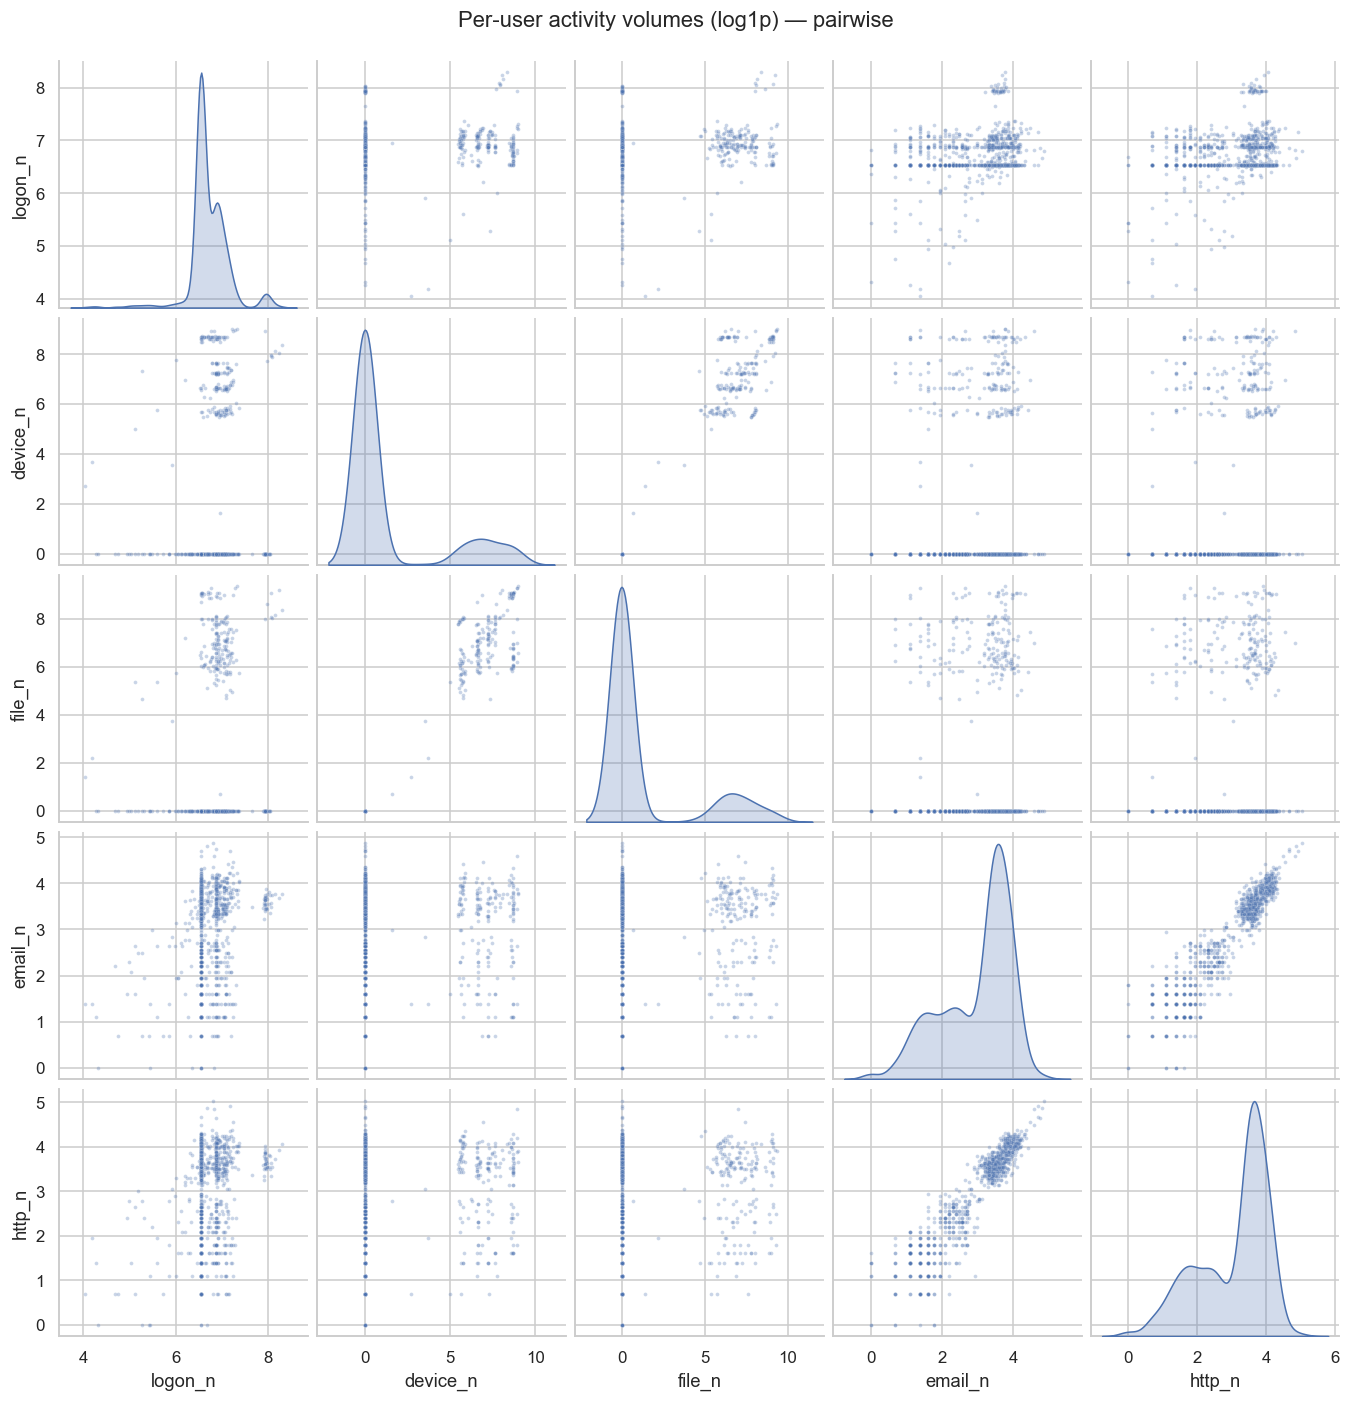

In [99]:
g = sns.pairplot(np.log1p(act), diag_kind='kde', plot_kws={'s': 6, 'alpha': 0.3})
g.fig.suptitle('Per-user activity volumes (log1p) — pairwise', y=1.02)
plt.show()

**Read:** Activity counts across modalities are positively but moderately correlated — knowing logon volume tells you something about file/device volume but not everything. Each modality still carries unique signal, which justifies a multi-input model in Week 6.